# โครงการวิจัย: การพัฒนาแพลตฟอร์มปัญญาประดิษฐ์บนอุปกรณ์พกพาสำหรับจำแนกแมลงศัตรูข้าวและให้คำแนะนำเชิงปฏิบัติแบบเรียลไทม์

สมุดบันทึกนี้ออกแบบมาเพื่อการฝึกสอน ตรวจสอบ และแปลงโมเดลปัญญาประดิษฐ์สำหรับการจำแนกแมลงศัตรูข้าว 22 ชนิดของประเทศไทย เพื่อรองรับการนำไปติดตั้งบนแอปพลิเคชันมือถือ (TensorFlow Lite)

### 📋 สถาปัตยกรรมและเวิร์กโฟลว์ของสมุดบันทึก
1. **ระบบเตรียมความพร้อม**: เชื่อมต่อ Google Drive และตั้งค่าสภาพแวดล้อม (TensorFlow T4 GPU)
2. **พาธสำหรับ Dataset**: ตรวจสอบตำแหน่งโฟลเดอร์ภาพและไฟล์คำแนะนำ
3. **ตรวจสอบจำนวนภาพสองแหล่งข้อมูลใน GBIF API**: ดึงชื่อวิทยาศาสตร์ทั้ง 2 แหล่งข้อมูล (แบบดั้งเดิม vs แบบใหม่) และวิเคราะห์จำนวนรูปภาพถ่ายที่มีอยู่บนฐานข้อมูลสากล GBIF
4. **การทำความสะอาดภาพ**: ตรวจสอบภาพชำรุดและลบไฟล์ภาพที่ไม่สมบูรณ์
5. **การบีบอัดและสำรองข้อมูลไปยัง Google Drive**: บีบอัดภาพแมลงเป็นไฟล์ `dataset.zip` และสำรองไฟล์ลง Google Drive เพื่อแก้ปัญหาขีดจำกัดไฟล์ย่อยจำนวนมาก
6. **การเตรียมหน่วยความจำท้องถิ่นประสิทธิภาพสูง**: คัดลอก `dataset.zip` จาก Google Drive มาที่เครื่องประมวลผล Colab VM SSD แล้วแตกไฟล์สำหรับการรันกระบวนการเทรนอย่างรวดเร็ว
7. **การแบ่งชุดข้อมูล**: ทำการแบ่งชุดข้อมูล (Train 80% / Val 20%) และเพิ่มความทนทานโมเดลด้วย **Data Augmentation**
8. **การฝึกสอนและเปรียบเทียบโมเดล (Two-Phase Transfer Learning)**:
   - **โมเดลที่เปรียบเทียบ**: `MobileNetV2`, `EfficientNetB0`, `ResNet50V2`
   - **เฟสที่ 1 (Feature Extraction)**: ตรึงน้ำหนักของ Base Network และฝึกสอนเฉพาะชั้นจำแนก
   - **เฟสที่ 2 (Fine-Tuning)**: ปลดล็อกเลเยอร์ระดับสูง (Top Layers) ของแบบจำลองและจูนรายละเอียดด้วยอัตราการเรียนรู้ระดับต่ำสุด
9. **การประเมินและเปรียบเทียบ**: พล็อตและวิเคราะห์กราฟความถูกต้อง (Accuracy) และความสูญเสีย (Loss)
10. **การแปลงน้ำหนักโมเดล**: ส่งออกโมเดลที่ดีที่สุดเป็นไฟล์ `.tflite` สำหรับติดตั้งบนอุปกรณ์พกพา
11. **ระบบผู้เชี่ยวชาญ (Inference with Real-time Advice)**: การจำแนกภาพแมลงเดี่ยวและเชื่อมโยงคำแนะนำเกษตรจากไฟล์ `recommendations.json` ทันที

## 🛠️ ส่วนที่ 1: การโหลดไลบรารีที่จำเป็นและการตั้งค่าอุปกรณ์ประมวลผล

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import urllib.request
import urllib.parse
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow Version:", tf.__version__)
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    print('WARNING: GPU device not found. Please change runtime to GPU (T4).')
else:
    print('Success: Found GPU at:', device_name)

TensorFlow Version: 2.20.0
Success: Found GPU at: /device:GPU:0


## 📂 ส่วนที่ 2: เชื่อมต่อ Google Drive และตั้งค่าพาธสำหรับ Dataset

In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    # พาธมาตรฐานเมื่อนำโฟลเดอร์ไปวางใน Google Drive
    DATASET_DIR = '/content/drive/MyDrive/Colab Notebooks/insect/dataset/images'
    RECOMMENDATIONS_PATH = '/content/drive/MyDrive/Colab Notebooks/insect/data/recommendations.json'
except:
    print("Running on local machine or standard workspace.")
    DATASET_DIR = 'dataset/images'
    RECOMMENDATIONS_PATH = 'data/recommendations.json'

print("Checking Dataset location:", DATASET_DIR)
if os.path.exists(DATASET_DIR):
    classes = sorted(os.listdir(DATASET_DIR))
    print(f"Found {len(classes)} classes of rice insect pests:")
    for idx, cls in enumerate(classes):
        count = len(os.listdir(os.path.join(DATASET_DIR, cls)))
        print(f"{idx+1}. {cls}: {count} images")
else:
    print("Error: Dataset directory not found. Please upload dataset/images to your workspace or Google Drive.")

Mounted at /content/drive
Checking Dataset location: /content/drive/MyDrive/Colab Notebooks/insect/dataset/images
Found 17 classes of rice insect pests:
1. มวนง่าม: 46 images
2. หนอนกระทู้กล้า: 150 images
3. หนอนกระทู้คอรวง: 148 images
4. หนอนกอข้าวสีครีม: 148 images
5. หนอนกอสีชมพู: 65 images
6. หนอนกอแถบลายเล็ก: 56 images
7. หนอนปลอกข้าว: 150 images
8. หนอนห่อใบข้าว: 146 images
9. เพลี่ยกระโดดหลังขาว: 150 images
10. เพลี้ยกระโดดสีน้ำตาล: 149 images
11. เพลี้ยจักจั่นสีเขียว: 75 images
12. เพลี้ยแป้ง: 54 images
13. เพลี้ยไฟ: 144 images
14. แมลงดำหนาม: 13 images
15. แมลงบั่ว: 22 images
16. แมลงสิง: 150 images
17. แมลงหล่า: 97 images


## 🌐 ส่วนที่ 3: การตรวจสอบและแปลงข้อมูลจำนวนภาพบนคลังข้อมูลโลก GBIF (Query GBIF Counts with TaxonKey Match)
ส่วนนี้จะทำการอ่านไฟล์คำแนะนำภาษาไทยและดึงชื่อวิทยาศาสตร์ใหม่ (scientific_name_2) จากนั้นทำการค้นหาข้อมูลทางอนุกรมวิธานผ่าน **GBIF Species Match API** เพื่อแปลงชื่อให้เป็นรหัสอ้างอิง `taxonKey` สากล (ช่วยแก้ไขปัญหาการสะกดผิดหรือมีชื่อผู้ค้นพบปะปน) และส่งสืบค้นไปยัง GBIF Occurrence API เพื่อสรุปจำนวนภาพและข้อมูลอนุกรมวิธานในรูปแบบไฟล์ JSON (`gbif_summary.json`)


In [4]:
print("Reading recommendations.json from:", RECOMMENDATIONS_PATH)
if os.path.exists(RECOMMENDATIONS_PATH):
    with open(RECOMMENDATIONS_PATH, 'r', encoding='utf-8') as f:
        pest_db = json.load(f)
    
    gbif_results = []
    gbif_summary = {}
    print("Querying GBIF Backbone Taxonomy and Occurrence APIs (Option 1 - TaxonKey match)...\n")
    
    for thai_name, info in pest_db.items():
        name2 = info.get('scientific_name_2', '')
        
        taxon_key = None
        matched_sci_name = ""
        status = ""
        rank = ""
        confidence = 0
        match_type = ""
        kingdom = ""
        phylum = ""
        class_name = ""
        order = ""
        family = ""
        genus = ""
        
        if name2:
            match_url = f"https://api.gbif.org/v1/species/match?name={urllib.parse.quote(name2)}"
            try:
                with urllib.request.urlopen(match_url, timeout=10) as r:
                    res = json.loads(r.read().decode('utf-8'))
                    taxon_key = res.get('usageKey') or res.get('speciesKey')
                    matched_sci_name = res.get('scientificName', '')
                    status = res.get('status', '')
                    rank = res.get('rank', '')
                    confidence = res.get('confidence', 0)
                    match_type = res.get('matchType', '')
                    kingdom = res.get('kingdom', '')
                    phylum = res.get('phylum', '')
                    class_name = res.get('class', '')
                    order = res.get('order', '')
                    family = res.get('family', '')
                    genus = res.get('genus', '')
            except Exception as e:
                print(f"Error matching {name2}: {e}")
                
        # คิวรีหาจำนวนภาพโดยใช้ taxonKey
        count = 0
        if taxon_key:
            occ_url = f"https://api.gbif.org/v1/occurrence/search?taxonKey={taxon_key}&mediaType=StillImage&limit=0"
            try:
                with urllib.request.urlopen(occ_url, timeout=10) as r:
                    count = json.loads(r.read().decode('utf-8')).get('count', 0)
            except Exception as e:
                count = "Error"
        else:
            count = "-"
            
        gbif_results.append({
            "ชื่อภาษาไทย": thai_name,
            "ชื่อวิทยาศาสตร์ 2 (ใหม่)": name2,
            "ชื่อวิทย์ที่ตรงบน GBIF": matched_sci_name,
            "Taxon Key": taxon_key,
            "จำนวนภาพ (GBIF)": count
        })
        print(f"- {thai_name}: {name2} -> GBIF: {matched_sci_name} ({count} ภาพ)")
        
        # เก็บข้อมูลสรุปลง dict เพื่อแปลงเป็น JSON
        gbif_summary[thai_name] = {
            "thai_name": thai_name,
            "image_count": count,
            "scientific_name_2": name2,
            "gbif_scientific_name": matched_sci_name,
            "taxon_key": taxon_key,
            "status": status,
            "rank": rank,
            "confidence": confidence,
            "match_type": match_type,
            "kingdom": kingdom,
            "phylum": phylum,
            "class": class_name,
            "order": order,
            "family": family,
            "genus": genus
        }
        
    # แปลงเป็น DataFrame และแสดงตาราง
    df_gbif = pd.DataFrame(gbif_results)
    print("\n=== ตารางสรุปจำนวนภาพถ่ายจากการใช้ TaxonKey แมชชิ่งบน GBIF ===")
    display(df_gbif)
    
    # บันทึกไฟล์ JSON สรุปข้อมูลแมลงใหม่ตามคำร้องขอ
    summary_json_path = os.path.join(os.path.dirname(RECOMMENDATIONS_PATH), "gbif_summary.json")
    with open(summary_json_path, 'w', encoding='utf-8') as f:
        json.dump(gbif_summary, f, indent=4, ensure_ascii=False)
    print(f"\nบันทึกข้อมูลสรุปในรูปแบบ JSON สำเร็จที่: {summary_json_path}")
else:
    print(f"Error: recommendations.json not found at {RECOMMENDATIONS_PATH}")

Reading recommendations.json from: /content/drive/MyDrive/Colab Notebooks/insect/data/recommendations.json
Querying GBIF Backbone Taxonomy and Occurrence APIs (Option 1 - TaxonKey match)...

- ด้วงงวงกินรากข้าว: Hydronomidius molitor Faust -> GBIF: Hydronomidius molitor Faust, 1898 (0 ภาพ)
- ด้วงดำ: Heteronychus lioderes Redtenbacher -> GBIF: Heteronychus lioderes Redtenbacher, 1868 (0 ภาพ)
- มวนง่าม: Tetroda denticulifera (Berg) -> GBIF: Tetroda Amyot & Serville, 1843 (46 ภาพ)
- หนอนกระทู้กล้า: Spodoptera mauritia (Boisduval) -> GBIF: Spodoptera mauritia (Boisduval, 1833) (2488 ภาพ)
- หนอนกระทู้คอรวง: Mythimna separata (Walker) -> GBIF: Mythimna separata (Walker, 1865) (860 ภาพ)
- หนอนกอข้าวสีครีม: Scirpophaga incertulas (Walker) -> GBIF: Scirpophaga incertulas Walker, 1863 (438 ภาพ)
- หนอนกอสีชมพู: Sesamia inferens (Walker) -> GBIF: Sesamia inferens (Walker, 1856) (96 ภาพ)
- หนอนกอแถบลายสีม่วง: Chilo polychrysus (Meyrick) -> GBIF: Chilo polychrysa Meyrick, 1932 (0 ภาพ)
- หนอนกอแถบลาย

,ชื่อภาษาไทย,ชื่อวิทยาศาสตร์ 2 (ใหม่),ชื่อวิทย์ที่ตรงบน GBIF,Taxon Key,จำนวนภาพ (GBIF)
0,ด้วงงวงกินรากข้าว,Hydronomidius molitor Faust,"Hydronomidius molitor Faust, 1898",1247989,0
1,ด้วงดำ,Heteronychus lioderes Redtenbacher,"Heteronychus lioderes Redtenbacher, 1868",4995399,0
2,มวนง่าม,Tetroda denticulifera (Berg),"Tetroda Amyot & Serville, 1843",4783006,46
3,หนอนกระทู้กล้า,Spodoptera mauritia (Boisduval),"Spodoptera mauritia (Boisduval, 1833)",5109848,2488
4,หนอนกระทู้คอรวง,Mythimna separata (Walker),"Mythimna separata (Walker, 1865)",5802396,860
5,หนอนกอข้าวสีครีม,Scirpophaga incertulas (Walker),"Scirpophaga incertulas Walker, 1863",1881293,438
6,หนอนกอสีชมพู,Sesamia inferens (Walker),"Sesamia inferens (Walker, 1856)",1762353,96
7,หนอนกอแถบลายสีม่วง,Chilo polychrysus (Meyrick),"Chilo polychrysa Meyrick, 1932",1883232,0
8,หนอนกอแถบลายเล็ก,Chilo suppressalis (Walker),"Chilo suppressalis Walker, 1863",1883226,56
9,หนอนปลอกข้าว,Nymphula depunctalis Guenée,"Nymphula Schrank, 1802",1884090,7081



บันทึกข้อมูลสรุปในรูปแบบ JSON สำเร็จที่: /content/drive/MyDrive/Colab Notebooks/insect/data/gbif_summary.json


## 🧹 ส่วนที่ 4: การดาวน์โหลดภาพจาก GBIF และตรวจสอบความถูกต้องของข้อมูล (Image Download & Data Integrity Check)
ส่วนนี้จะทำการดึงข้อมูลสายพันธุ์จากไฟล์ `gbif_summary.json` และส่งคำขอสืบค้นไปยัง GBIF API เพื่อดาวน์โหลดภาพแมลงศัตรูข้าวแต่ละชนิดสูงสุด 100 ภาพต่อชนิด โดยบันทึกไฟล์ด้วยชื่อรหัส `key` ของ GBIF (เพื่อป้องกันการดาวน์โหลดซ้ำ) พร้อมกับตรวจสอบการชำรุดของภาพและทำการปรับขนาดภาพแบบรักษาอัตราส่วน (Letterbox Resizing with Padding ขนาด 224x224 พิกเซล) ก่อนจัดเก็บลงดิสก์

In [ ]:
import os
import json
import urllib.request
import urllib.parse
import io
import numpy as np
import cv2
from PIL import Image

def download_and_resize_gbif_images(summary_json_path, dataset_dir, limit_per_species=150, target_size=(224, 224), padding_color=(255, 255, 255)):
    if not os.path.exists(summary_json_path):
        print(f"Error: {summary_json_path} not found.")
        return
        
    with open(summary_json_path, 'r', encoding='utf-8') as f:
        summary_db = json.load(f)
        
    print(f"Loaded {len(summary_db)} species from summary JSON.")
    
    # วนลูปดาวน์โหลดภาพแต่ละสปีชีส์
    for thai_name, info in summary_db.items():
        taxon_key = info.get('taxon_key')
        image_count = info.get('image_count', 0)
        
        if not taxon_key or image_count == 0 or image_count == '-':
            print(f"\n- {thai_name}: ไม่มีภาพบน GBIF (ข้าม)")
            continue
            
        species_dir = os.path.join(dataset_dir, thai_name)
        os.makedirs(species_dir, exist_ok=True)
        
        # สืบค้นรายการ Occurrence สูงสุด 150 รายการ
        occ_limit = min(limit_per_species, int(image_count))
        print(f"\n- {thai_name}: กำลังดึงรายการภาพจาก GBIF (ต้องการสูงสุด {occ_limit} ภาพ)...")
        
        occ_url = f"https://api.gbif.org/v1/occurrence/search?taxonKey={taxon_key}&mediaType=StillImage&limit={limit_per_species}"
        try:
            with urllib.request.urlopen(occ_url, timeout=10) as r:
                res = json.loads(r.read().decode('utf-8'))
                occurrences = res.get('results', [])
        except Exception as e:
            print(f"  Error fetching occurrences for {thai_name}: {e}")
            continue
            
        downloaded_count = 0
        skipped_count = 0
        failed_count = 0
        
        for occ in occurrences:
            # ตรวจสอบขีดจำกัด
            if downloaded_count >= limit_per_species:
                break
                
            occ_key = occ.get('key')
            media_list = occ.get('media', [])
            if not occ_key or not media_list:
                continue
                
            # หา StillImage URL แรก
            img_url = None
            for m in media_list:
                if m.get('type') == 'StillImage' and m.get('identifier'):
                    img_url = m.get('identifier')
                    break
                    
            if not img_url:
                continue
                
            save_path = os.path.join(species_dir, f"{occ_key}.jpg")
            
            # ตรวจสอบการดาวน์โหลดซ้ำ
            if os.path.exists(save_path):
                # ตรวจสอบว่าไฟล์ที่โหลดมาก่อนหน้านี้ชำรุดหรือไม่
                try:
                    with Image.open(save_path) as img:
                        img.verify()
                    skipped_count += 1
                    downloaded_count += 1
                    continue
                except:
                    print(f"  ตรวจพบภาพเดิมชำรุด จะทำการดาวน์โหลดใหม่: {save_path}")
                    try:
                        os.remove(save_path)
                    except:
                        pass
                        
            # ดาวน์โหลดและตรวจสภาพภาพชำรุด
            try:
                # สร้าง Request พร้อม User-Agent เพื่อหลีกเลี่ยงการโดนบล็อก
                req = urllib.request.Request(
                    img_url, 
                    headers={'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
                )
                with urllib.request.urlopen(req, timeout=15) as resp:
                    img_bytes = resp.read()
                    
                # ตรวจสอบความชำรุดของภาพด้วย PIL
                img_pil = Image.open(io.BytesIO(img_bytes))
                img_pil.verify()
                
                # ถอดรหัสภาพด้วย OpenCV
                img_bgr = cv2.imdecode(np.frombuffer(img_bytes, np.uint8), cv2.IMREAD_COLOR)
                if img_bgr is None:
                    raise ValueError("OpenCV imdecode returned None")
                    
                # ปรับขนาดภาพแบบ Letterbox Resizing with Padding (รักษารูปทรงสัณฐาน)
                h, w = img_bgr.shape[:2]
                target_w, target_h = target_size
                scale = min(target_w / w, target_h / h)
                new_w = int(w * scale)
                new_h = int(h * scale)
                
                resized = cv2.resize(img_bgr, (new_w, new_h), interpolation=cv2.INTER_AREA)
                padded = np.full((target_h, target_w, 3), padding_color, dtype=np.uint8)
                
                x_offset = (target_w - new_w) // 2
                y_offset = (target_h - new_h) // 2
                padded[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = resized
                
                # บันทึกภาพลงดิสก์
                cv2.imwrite(save_path, padded)
                downloaded_count += 1
            except Exception as e:
                failed_count += 1
                
        print(f"  -> สรุป: โหลดสำเร็จ {downloaded_count} ภาพ (ข้ามภาพซ้ำ {skipped_count} ภาพ, ล้มเหลว {failed_count} ภาพ)")

def check_and_clean_images(directory):
    corrupted_files = []
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.webp', '.bmp')):
                file_path = os.path.join(root, file)
                try:
                    with Image.open(file_path) as img:
                        img.verify()
                except Exception as e:
                    print(f"Corrupted image detected: {file_path} - Error: {e}")
                    corrupted_files.append(file_path)
    return corrupted_files

# กำหนดโฟลเดอร์เก็บข้อมูลภาพ
if 'DATASET_DIR' not in globals():
    DATASET_DIR = 'dataset/images'
if 'RECOMMENDATIONS_PATH' not in globals():
    RECOMMENDATIONS_PATH = 'data/recommendations.json'

summary_json = os.path.join(os.path.dirname(RECOMMENDATIONS_PATH), "gbif_summary.json")

print("Starting GBIF images download and validation process...")
download_and_resize_gbif_images(summary_json, DATASET_DIR, limit_per_species=150)

print("\nScanning dataset for corrupted images...")
corrupted = check_and_clean_images(DATASET_DIR)
if len(corrupted) == 0:
    print("All images verified successfully. No corrupted files found!")
else:
    print(f"Found {len(corrupted)} corrupted files.")
    # ลบภาพชำรุดออกเพื่อความสะอาดของข้อมูล
    for path in corrupted:
        try:
            os.remove(path)
            print(f"Deleted corrupted file: {path}")
        except Exception as e:
            print(f"Failed to delete {path}: {e}")

Starting GBIF images download and validation process...
Loaded 22 species from summary JSON.

- ด้วงงวงกินรากข้าว: ไม่มีภาพบน GBIF (ข้าม)

- ด้วงดำ: ไม่มีภาพบน GBIF (ข้าม)

- มวนง่าม: กำลังดึงรายการภาพจาก GBIF (ต้องการสูงสุด 46 ภาพ)...
  -> สรุป: โหลดสำเร็จ 46 ภาพ (ข้ามภาพซ้ำ 46 ภาพ, ล้มเหลว 0 ภาพ)

- หนอนกระทู้กล้า: กำลังดึงรายการภาพจาก GBIF (ต้องการสูงสุด 150 ภาพ)...
  -> สรุป: โหลดสำเร็จ 150 ภาพ (ข้ามภาพซ้ำ 150 ภาพ, ล้มเหลว 0 ภาพ)

- หนอนกระทู้คอรวง: กำลังดึงรายการภาพจาก GBIF (ต้องการสูงสุด 150 ภาพ)...
  -> สรุป: โหลดสำเร็จ 148 ภาพ (ข้ามภาพซ้ำ 148 ภาพ, ล้มเหลว 2 ภาพ)

- หนอนกอข้าวสีครีม: กำลังดึงรายการภาพจาก GBIF (ต้องการสูงสุด 150 ภาพ)...
  -> สรุป: โหลดสำเร็จ 148 ภาพ (ข้ามภาพซ้ำ 148 ภาพ, ล้มเหลว 2 ภาพ)

- หนอนกอสีชมพู: กำลังดึงรายการภาพจาก GBIF (ต้องการสูงสุด 96 ภาพ)...
  -> สรุป: โหลดสำเร็จ 65 ภาพ (ข้ามภาพซ้ำ 65 ภาพ, ล้มเหลว 31 ภาพ)

- หนอนกอแถบลายสีม่วง: ไม่มีภาพบน GBIF (ข้าม)

- หนอนกอแถบลายเล็ก: กำลังดึงรายการภาพจาก GBIF (ต้องการสูงสุด 56 ภาพ)...
  -> สรุป: โหลดสำเร็จ 56 ภาพ (

  ตรวจพบภาพเดิมชำรุด จะทำการดาวน์โหลดใหม่: /content/drive/MyDrive/Colab Notebooks/insect/dataset/images/เพลี้ยกระโดดสีน้ำตาล/4916242498.jpg


## 📦 ส่วนที่ 5: การบีบอัดและสำรองข้อมูลชุดรูปภาพไปยัง Google Drive (Zip Dataset for Backup)
หลังจากดาวน์โหลดรูปภาพแมลงศัตรูข้าวเสร็จเรียบร้อยแล้ว การจัดเก็บไฟล์รูปภาพเป็นหมื่นๆ ไฟล์ย่อยโดยตรงบน Google Drive จะมีความล่าช้าสูงและอาจทำให้เกิดข้อผิดพลาดในการโหลดระบบคลังข้อมูลได้ ดังนั้นเราจะใช้วิธีบีบอัดเป็นไฟล์ `dataset.zip` เพียงก้อนเดียว แล้วอัปโหลดไปเก็บสำรองบน Google Drive เพื่อเสถียรภาพและความปลอดภัยของข้อมูล

In [10]:
import os
import shutil
import subprocess

# กำหนดโฟลเดอร์รูปภาพต้นทางที่ต้องการบีบอัด และตำแหน่งจัดเก็บ zip ปลายทางบน Drive
source_dir = '/content/drive/MyDrive/Colab Notebooks/insect/dataset/images' 
backup_zip_dir = '/content/drive/MyDrive/Colab Notebooks/insect'
backup_zip_path = os.path.join(backup_zip_dir, 'dataset.zip')

try:
    if os.path.exists(source_dir):
        os.makedirs(backup_zip_dir, exist_ok=True)
        
        # ค้นหาไดเรกทอรีแม่และชื่อโฟลเดอร์ปลายทาง
        parent_dir = os.path.dirname(source_dir)
        base_dir = os.path.basename(source_dir)
        
        # หากรันบน Google Colab (มีโฟลเดอร์ /content)
        if os.path.exists('/content'):
            print(f"กำลังบีบอัดโฟลเดอร์ {source_dir} เป็นไฟล์ dataset.zip บน Google Drive...")
            
            # ย้ายโฟลเดอร์การทำงานไปยัง parent_dir ก่อน แล้วบีบอัดเฉพาะโฟลเดอร์ images (base_dir)
            zip_cmd = f'cd "{parent_dir}" && zip -r -q "{backup_zip_path}" "{base_dir}"'
            result = subprocess.run(zip_cmd, shell=True, capture_output=True, text=True)
            
            if result.returncode == 0:
                print(f"สำรองข้อมูลสำเร็จเรียบร้อยที่: {backup_zip_path}")
            else:
                print(f"การบีบอัดผ่าน cmd ล้มเหลว: {result.stderr}")
                print("กำลังใช้วิธีสำรองบีบอัดผ่าน Python shutil...")
                shutil.make_archive('dataset', 'zip', parent_dir, base_dir)
                shutil.copy('dataset.zip', backup_zip_path)
                os.remove('dataset.zip')
                print(f"สำรองข้อมูลสำเร็จเรียบร้อยที่: {backup_zip_path}")
        else:
            # สำหรับการรันบน Local PC ทั่วไป
            source_dir_local = 'dataset/images'
            if os.path.exists(source_dir_local):
                parent_dir_local = os.path.dirname(source_dir_local)
                base_dir_local = os.path.basename(source_dir_local)
                shutil.make_archive('dataset', 'zip', parent_dir_local, base_dir_local)
                shutil.copy('dataset.zip', backup_zip_path)
                os.remove('dataset.zip')
                print(f"สำรองข้อมูลสำเร็จเรียบร้อยที่: {backup_zip_path}")
            else:
                print(f"ไม่พบโฟลเดอร์รูปภาพท้องถิ่นที่: {source_dir_local}")
    else:
        print(f"ไม่พบโฟลเดอร์รูปภาพต้นทางที่: {source_dir} (ข้ามขั้นตอนการสำรองข้อมูล)")
except Exception as e:
    print(f"เกิดข้อผิดพลาดในการสำรองข้อมูล: {e}")

กำลังบีบอัดโฟลเดอร์ /content/drive/MyDrive/Colab Notebooks/insect/dataset/images เป็นไฟล์ dataset.zip บน Google Drive...
สำรองข้อมูลสำเร็จเรียบร้อยที่: /content/drive/MyDrive/Colab Notebooks/insect/dataset.zip


## ⚡ ส่วนที่ 6: การเตรียมชุดข้อมูลความเร็วสูงบนหน่วยความจำเครื่อง Local VM SSD (Unzip Dataset for High-Speed Training)
เพื่อป้องกันปัญหาการดึงรูปภาพช้าจากคลังเก็บไฟล์ย่อยบน Google Drive ระหว่างขั้นตอนการเทรน ซึ่งเป็นสาเหตุให้ความเร็วในการเทรนโมเดลช้าลงมาก เราจะคัดลอกไฟล์ `dataset.zip` จาก Google Drive มายังดิสก์ Local VM ของ Google Colab โดยตรง แล้วคลายไฟล์เพื่อการอ่านรูปภาพผ่าน Local SSD ซึ่งรวดเร็วกว่าหลายเท่าตัว

In [3]:
import os
import zipfile
import shutil

# กำหนดโฟลเดอร์และไฟล์ zip ที่ต้องการคัดลอกมาแตกไฟล์ชั่วคราวใน Local Colab VM
drive_zip_path = '/content/drive/MyDrive/Colab Notebooks/insect/dataset.zip'
local_zip_path = '/content/dataset.zip'
local_extract_dir = '/content/dataset_local'

try:
    if os.path.exists('/content') and os.path.exists(drive_zip_path):
        print("พบไฟล์สำรองบน Google Drive กำลังคัดลอกมายังหน่วยความจำเครื่อง Colab VM SSD...")
        shutil.copy(drive_zip_path, local_zip_path)
        
        print("กำลังแตกไฟล์ชุดข้อมูลรูปภาพไปยังเครื่อง...")
        with zipfile.ZipFile(local_zip_path, 'r') as zip_ref:
            zip_ref.extractall(local_extract_dir)
        
        print("แตกไฟล์เสร็จสิ้นและจัดเก็บไว้บนดิสก์ความเร็วสูงของ Colab VM สำเร็จ!")
        # ลบไฟล์ zip ชั่วคราวออกเพื่อคืนพื้นที่ระบบ
        os.remove(local_zip_path)
    else:
        print("ไม่พบ Google Drive หรือไม่มีไฟล์ dataset.zip สำรองอยู่ (ข้ามขั้นตอนการแตกไฟล์)")
        print("กรุณาตรวจสอบว่ามีไฟล์สำรองบน Drive และได้เมาท์ Drive สำเร็จแล้ว")
except Exception as e:
    print(f"เกิดข้อผิดพลาดในการเตรียมหน่วยความจำชั่วคราว: {e}")

พบไฟล์สำรองบน Google Drive กำลังคัดลอกมายังหน่วยความจำเครื่อง Colab VM SSD...
กำลังแตกไฟล์ชุดข้อมูลรูปภาพไปยังเครื่อง...
แตกไฟล์เสร็จสิ้นและจัดเก็บไว้บนดิสก์ความเร็วสูงของ Colab VM สำเร็จ!


## 🔄 ส่วนที่ 7: การจัดแบ่งชุดข้อมูลการเทรนและ Data Augmentation
เราจะประยุกต์ใช้ ImageDataGenerator ร่วมกับการหมุนสุ่ม พลิกภาพ และการสเกลขนาดสำหรับ Train และ Validation ในอัตราส่วน 80:20 เพื่อลดโอกาสเกิด Overfitting

In [4]:
# --- [ตั้งค่าพาธสำหรับรันคลังรูปภาพในบล็อกนี้] ---
# คุณสามารถเปลี่ยนค่าพาธนี้ได้ในแต่ละบล็อกเพื่อการรันเฉพาะส่วนตามความเหมาะสม
# - กรณีเทรนจาก Local SSD (แนะนำ): ให้ตั้งเป็น '/content/dataset_local/images'
# - กรณีเทรนจาก Google Drive โดยตรง: ให้ตั้งเป็น '/content/drive/MyDrive/Colab Notebooks/insect/dataset/images'
import os
DATASET_DIR = '/content/dataset_local/images' if os.path.exists('/content/dataset_local/images') else 'dataset/images'
print("โฟลเดอร์ภาพที่ใช้ในการแบ่งข้อมูลฝึกสอนหลัก:", DATASET_DIR)
# ---------------------------------------------

BATCH_SIZE = 16
IMAGE_SIZE = (224, 224)

# ใช้เทคนิคการขยายข้อมูล (Data Augmentation) สำหรับชุดฝึกสอน
train_datagen = ImageDataGenerator(
    rescale=1./255,               # ทำการ Normalization ปรับช่วงสีจาก 0-255 เป็น 0-1
    rotation_range=20,            # สุ่มหมุนภาพไม่เกิน 20 องศา
    width_shift_range=0.1,        # สุ่มเลื่อนด้านข้าง
    height_shift_range=0.1,       # สุ่มเลื่อนแนวตั้ง
    zoom_range=0.1,               # สุ่มซูม
    brightness_range=[0.9, 1.1],  # สุ่มปรับระดับความสว่าง
    horizontal_flip=True,         # สุ่มพลิกภาพแนวตั้งหรือแนวนอน
    validation_split=0.2          # กำหนดสัดส่วนแบ่งทำชุดตรวจสอบ 20%
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# โหลดข้อมูล Train (80%)
train_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42,
    shuffle=True
)

# โหลดข้อมูล Validation (20%)
val_generator = val_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42,
    shuffle=False
)

num_classes = len(train_generator.class_indices)
print("Detected number of classes:", num_classes)
print("Class Map:", train_generator.class_indices)

โฟลเดอร์ภาพที่ใช้ในการแบ่งข้อมูลฝึกสอนหลัก: /content/dataset_local/images
Found 1416 images belonging to 17 classes.
Found 347 images belonging to 17 classes.
Detected number of classes: 17
Class Map: {'มวนง่าม': 0, 'หนอนกระทู้กล้า': 1, 'หนอนกระทู้คอรวง': 2, 'หนอนกอข้าวสีครีม': 3, 'หนอนกอสีชมพู': 4, 'หนอนกอแถบลายเล็ก': 5, 'หนอนปลอกข้าว': 6, 'หนอนห่อใบข้าว': 7, 'เพลี่ยกระโดดหลังขาว': 8, 'เพลี้ยกระโดดสีน้ำตาล': 9, 'เพลี้ยจักจั่นสีเขียว': 10, 'เพลี้ยแป้ง': 11, 'เพลี้ยไฟ': 12, 'แมลงดำหนาม': 13, 'แมลงบั่ว': 14, 'แมลงสิง': 15, 'แมลงหล่า': 16}


## 🧠 ส่วนที่ 8: การสร้าง ฝึกสอน และเปรียบเทียบสถาปัตยกรรมโมเดล Deep Learning
เราทำการเปรียบเทียบโมเดล 3 โมเดล ได้แก่ `MobileNetV2` (น้ำหนักเบา รันบนมือถือดีเยี่ยม), `EfficientNetB0` (ค่าความแม่นยำคุ้มค่าสเกลพารามิเตอร์) และ `ResNet50V2` (โครงสร้างลึกทรงประสิทธิภาพ)

In [5]:
def build_transfer_learning_model(model_name, input_shape=(224, 224, 3), num_classes=22):
    """
    สร้างแบบจำลองโดยตรึงน้ำหนักโครงสร้างหลักที่ใช้ ImageNet และสวมหัว Classification เพิ่มเติม
    """
    # โมเดลแต่ละตัวต้องการการสเกลข้อมูล (Input Preprocessing) แตกต่างกัน:
    # - MobileNetV2 และ ResNet50V2 ต้องการข้อมูลสเกลอยู่ในช่วง [-1, 1]
    #   (เนื่องจาก Generator จ่ายข้อมูลสเกล [0, 1] เราจึงต้องแปลงโดยใช้ x * 2.0 - 1.0)
    # - EfficientNetB0 ต้องการข้อมูลช่วง [0, 255] เพราะมีโมดูล Rescaling(1./255) ฝังอยู่ด้านในแล้ว
    #   (เราจึงต้องแปลงจาก [0, 1] กลับไปเป็น [0, 255] โดยการคูณด้วย 255.0)
    if model_name == "MobileNetV2":
        preprocessing_layer = layers.Rescaling(scale=2.0, offset=-1.0, input_shape=input_shape)
        base_model = tf.keras.applications.MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')
    elif model_name == "EfficientNetB0":
        preprocessing_layer = layers.Rescaling(scale=255.0, input_shape=input_shape)
        base_model = tf.keras.applications.EfficientNetB0(input_shape=input_shape, include_top=False, weights='imagenet')
    elif model_name == "ResNet50V2":
        preprocessing_layer = layers.Rescaling(scale=2.0, offset=-1.0, input_shape=input_shape)
        base_model = tf.keras.applications.ResNet50V2(input_shape=input_shape, include_top=False, weights='imagenet')
    else:
        raise ValueError("Unknown model name")
        
    # ตรึงโมเดลหลัก (แช่แข็งค่าน้ำหนักฟีเจอร์)
    base_model.trainable = False

    model = models.Sequential([
        preprocessing_layer,
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model, base_model

### 8.1 เฟสแรก: การเรียนรู้สกัดฟีเจอร์ (Feature Extraction Phase)
ในส่วนนี้เราจะล็อคโครงสร้างด้านล่างไว้และเทรนเฉพาะ Classifier ด้านบนเป็นเวลา 20-30 epochs ด้วยอัตราการเรียนรู้เริ่มต้น $10^{-4}$

In [6]:
histories = {}
trained_models = {}

selected_models = ["MobileNetV2", "EfficientNetB0", "ResNet50V2"]

for name in selected_models:
    print(f"\n=== Start Feature Extraction for {name} ===")
    model, base_model = build_transfer_learning_model(name, num_classes=num_classes)
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4)
    ]
    
    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=30,  # เพิ่มเป็น 30 epochs (ปลอดภัยเนื่องจากมี EarlyStopping คอยหยุดคุม)
        callbacks=callbacks
    )
    
    histories[name] = history.history
    trained_models[name] = (model, base_model)

# --- [บันทึกประวัติการเทรนเฟสแรกแยกออกมาเป็นไฟล์ JSON] ---
history_fe_path = 'history_feature_extraction.json'
if os.path.exists('/content/drive/MyDrive/Colab Notebooks/insect'):
    history_fe_path = '/content/drive/MyDrive/Colab Notebooks/insect/history_feature_extraction.json'

with open(history_fe_path, 'w', encoding='utf-8') as f:
    json.dump(histories, f, indent=4, ensure_ascii=False)
print(f"=== บันทึกประวัติการเทรนเฟสแรกสำเร็จที่: {history_fe_path} ===")



=== Start Feature Extraction for MobileNetV2 ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 68s 543ms/step - accuracy: 0.2380 - loss: 2.5632 - val_accuracy: 0.5014 - val_loss: 1.8327 - learning_rate: 1.0000e-04
Epoch 2/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 21s 238ms/step - accuracy: 0.4845 - loss: 1.7146 - val_accuracy: 0.6628 - val_loss: 1.3219 - learning_rate: 1.0000e-04
Epoch 3/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 19s 218ms/step - accuracy: 0.5819 - loss: 1.3660 - val_accuracy: 0.7089 - val_loss: 1.0722 - learning_rate: 1.0000e-04
Epoch 4/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 21s 238ms/step - accuracy: 0.6645 - loss: 1.1146 - val_accuracy: 0.7608 - val_loss: 0.8850 - learning_rate: 1.0000e-04
Epoch 5/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 20s 221ms/step - accuracy: 0.6857 - loss: 1.0068 - val_accuracy: 0.7752 - val_loss: 0.7839 - learning_rate: 1.0000e-04
Epoch 6/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 21s 233ms/step - accuracy: 0.7323 - loss: 0.8894 - val_accuracy: 0.8242 - val_loss: 0.6833 - learning_rate: 1.0000e-04
Epoch 7/3

### 8.2 เฟสสอง: การปรับแต่งเชิงลึก (Fine-Tuning Phase)
ปลดล็อกโมดูลบล็อกท้ายๆ ของ Base model และฝึกสอนพร้อมกันด้วยอัตราการเรียนรู้ระดับต่ำมาก $10^{-5}$

In [7]:
fine_tune_histories = {}

for name in selected_models:
    print(f"\n=== Start Fine-Tuning for {name} ===")
    model, base_model = trained_models[name]
    
    base_model.trainable = True
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5)
    ]
    
    history_ft = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=50,  # เพิ่มเป็น 50 epochs สำหรับการจูนรายละเอียดเชิงลึกด้วย LR ระดับต่ำ
        callbacks=callbacks
    )
    
    fine_tune_histories[name] = history_ft.history

# --- [บันทึกประวัติการเทรนเฟสสองแยกออกมาเป็นไฟล์ JSON] ---
history_ft_path = 'history_fine_tuning.json'
if os.path.exists('/content/drive/MyDrive/Colab Notebooks/insect'):
    history_ft_path = '/content/drive/MyDrive/Colab Notebooks/insect/history_fine_tuning.json'

with open(history_ft_path, 'w', encoding='utf-8') as f:
    json.dump(fine_tune_histories, f, indent=4, ensure_ascii=False)
print(f"=== บันทึกประวัติการเทรนเฟสสองสำเร็จที่: {history_ft_path} ===")



=== Start Fine-Tuning for MobileNetV2 ===
Epoch 1/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 111s 670ms/step - accuracy: 0.6843 - loss: 1.0022 - val_accuracy: 0.8559 - val_loss: 0.3999 - learning_rate: 1.0000e-05
Epoch 2/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 23s 257ms/step - accuracy: 0.7373 - loss: 0.8186 - val_accuracy: 0.8559 - val_loss: 0.4185 - learning_rate: 1.0000e-05
Epoch 3/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 23s 255ms/step - accuracy: 0.7888 - loss: 0.6412 - val_accuracy: 0.8501 - val_loss: 0.4348 - learning_rate: 1.0000e-05
Epoch 4/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 22s 244ms/step - accuracy: 0.7910 - loss: 0.6430 - val_accuracy: 0.8559 - val_loss: 0.4456 - learning_rate: 1.0000e-05
Epoch 5/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 23s 259ms/step - accuracy: 0.8185 - loss: 0.5734 - val_accuracy: 0.8501 - val_loss: 0.4339 - learning_rate: 1.0000e-05
Epoch 6/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 22s 242ms/step - accuracy: 0.8383 - loss: 0.5104 - val_accuracy: 0.8415 - val_loss: 0.4374 - learning_rate: 1.0000e-05
Epoch 7/50
89/

## 📊 ส่วนที่ 9: พล็อตและเปรียบเทียบผลลัพธ์การฝึกสอน (Evaluation & Visualization)

กำลังโหลดประวัติการฝึกสอนเฟสแรกจาก: /content/drive/MyDrive/Colab Notebooks/insect/history_feature_extraction.json
กำลังโหลดประวัติการฝึกสอนเฟสสองจาก: /content/drive/MyDrive/Colab Notebooks/insect/history_fine_tuning.json
โหลดข้อมูลประวัติการเทรนสำเร็จ!


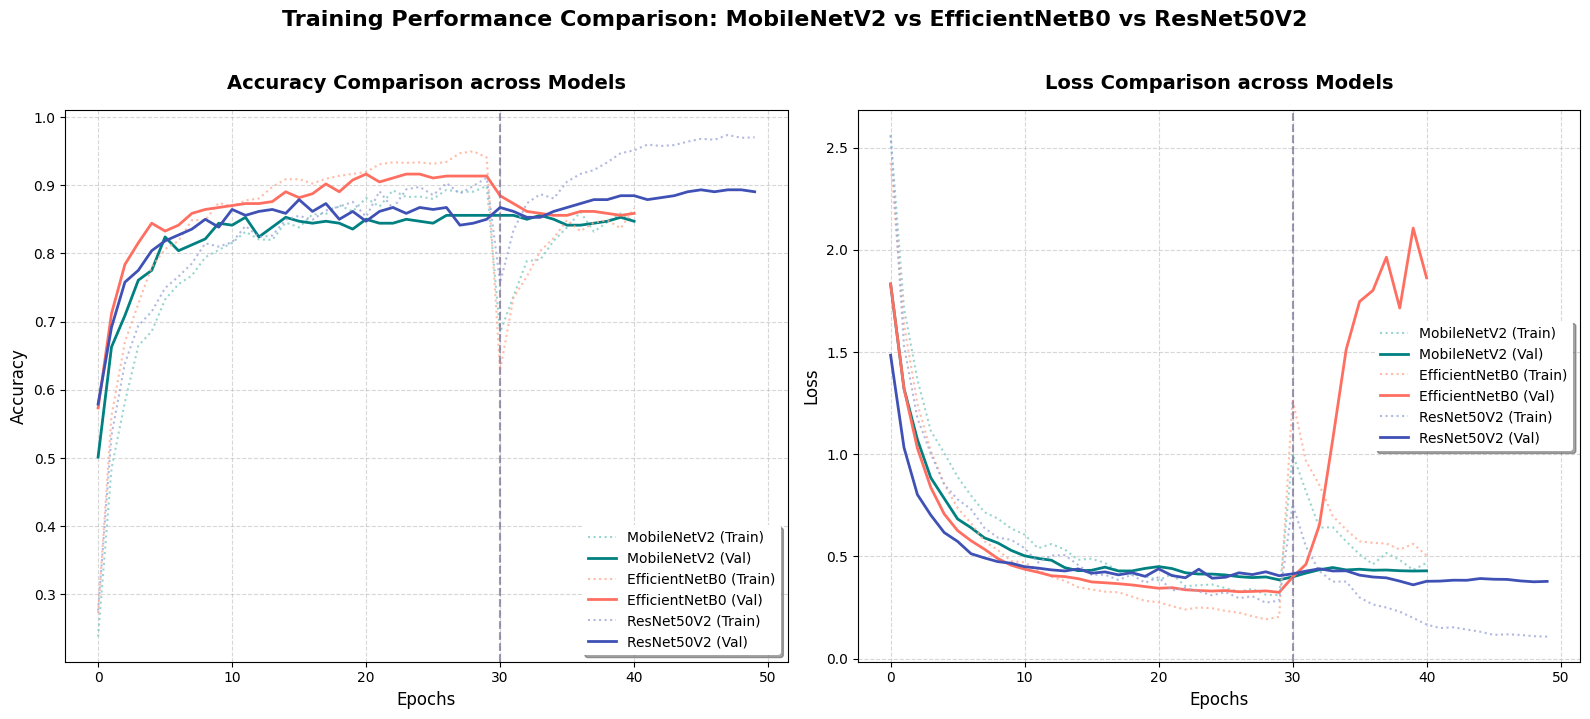

In [4]:
import os
import json
import matplotlib.pyplot as plt

# ดึงข้อมูลผลการเทรนมาจาก Google Drive ก่อนพล็อต
history_fe_path = 'history_feature_extraction.json'
history_ft_path = 'history_fine_tuning.json'

try:
    from google.colab import drive
    if not os.path.exists('/content/drive'):
        print("กำลังทำการเชื่อมต่อ Google Drive...")
        drive.mount('/content/drive')
    
    drive_folder = '/content/drive/MyDrive/Colab Notebooks/insect'
    if os.path.exists(drive_folder):
        history_fe_path = os.path.join(drive_folder, 'history_feature_extraction.json')
        history_ft_path = os.path.join(drive_folder, 'history_fine_tuning.json')
except Exception as e:
    print(f"ไม่ได้อยู่บน Google Colab หรือไม่สามารถเชื่อมต่อ Drive ได้ จะใช้พาธแบบ Local (รายละเอียด: {e})")

print(f"กำลังโหลดประวัติการฝึกสอนเฟสแรกจาก: {history_fe_path}")
print(f"กำลังโหลดประวัติการฝึกสอนเฟสสองจาก: {history_ft_path}")

try:
    with open(history_fe_path, 'r', encoding='utf-8') as f:
        histories = json.load(f)
    with open(history_ft_path, 'r', encoding='utf-8') as f:
        fine_tune_histories = json.load(f)
    print("โหลดข้อมูลประวัติการเทรนสำเร็จ!")
except FileNotFoundError as e:
    print(f"คำเตือน: ไม่พบไฟล์ผลการเทรนบน Drive/Local ระบบจะพยายามดึงข้อมูลจากตัวแปรเดิมในหน่วยความจำ (ถ้ามี)...")
    if 'histories' not in globals() or 'fine_tune_histories' not in globals():
        raise FileNotFoundError(f"ไม่พบไฟล์ประวัติการฝึกสอนและไม่มีตัวแปรที่ต้องการในหน่วยความจำ: {e}")

# ดึงรายชื่อโมเดลที่ถูกเทรน
if 'selected_models' not in globals() or not selected_models:
    selected_models = list(histories.keys())

# กำหนดสีพาเลทโทนพรีเมียมสำหรับแต่ละโมเดล
colors = {
    "MobileNetV2": {"train": "#80cbc4", "val": "#008080"},      # โทนเขียวเข้ม/อ่อน (Teal)
    "EfficientNetB0": {"train": "#ffab91", "val": "#ff6f61"},   # โทนส้ม/พีช (Coral)
    "ResNet50V2": {"train": "#9fa8da", "val": "#3f51b5"}       # โทนน้ำเงิน/ม่วง (Indigo)
}

plt.figure(figsize=(16, 7))

# --- พล็อตเปรียบเทียบ Accuracy ---
plt.subplot(1, 2, 1)
for name in selected_models:
    acc_total = histories[name]['accuracy'] + fine_tune_histories[name]['accuracy']
    val_acc_total = histories[name]['val_accuracy'] + fine_tune_histories[name]['val_accuracy']
    
    color_info = colors.get(name, {"train": "gray", "val": "black"})
    
    plt.plot(acc_total, label=f'{name} (Train)', color=color_info['train'], linestyle=':', alpha=0.8)
    plt.plot(val_acc_total, label=f'{name} (Val)', color=color_info['val'], linestyle='-', linewidth=2)
    
    # พล็อตเส้นประแนวตั้งเพื่อแสดงการเริ่ม Fine-Tuning
    ft_start = len(histories[name]['accuracy'])
    plt.axvline(x=ft_start, color=color_info['val'], linestyle='--', alpha=0.3)

plt.title('Accuracy Comparison across Models', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(frameon=True, facecolor='white', edgecolor='none', shadow=True)
plt.grid(True, linestyle='--', alpha=0.5)

# --- พล็อตเปรียบเทียบ Loss ---
plt.subplot(1, 2, 2)
for name in selected_models:
    loss_total = histories[name]['loss'] + fine_tune_histories[name]['loss']
    val_loss_total = histories[name]['val_loss'] + fine_tune_histories[name]['val_loss']
    
    color_info = colors.get(name, {"train": "gray", "val": "black"})
    
    plt.plot(loss_total, label=f'{name} (Train)', color=color_info['train'], linestyle=':', alpha=0.8)
    plt.plot(val_loss_total, label=f'{name} (Val)', color=color_info['val'], linestyle='-', linewidth=2)
    
    # พล็อตเส้นประแนวตั้งเพื่อแสดงการเริ่ม Fine-Tuning
    ft_start = len(histories[name]['accuracy'])
    plt.axvline(x=ft_start, color=color_info['val'], linestyle='--', alpha=0.3)

plt.title('Loss Comparison across Models', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(frameon=True, facecolor='white', edgecolor='none', shadow=True)
plt.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Training Performance Comparison: MobileNetV2 vs EfficientNetB0 vs ResNet50V2', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 💾 ส่วนที่ 10: บันทึกและแปลงโมเดลที่ดีที่สุดเป็น TensorFlow Lite (.tflite)
โมเดลจำแนกแมลงที่ฝึกสอนสมบูรณ์แล้วจะถูกเซฟเก็บและทำการแปลงเป็น TFLite เพื่อให้สามารถโหลดใช้งานอย่างรวดเร็วและใช้พลังงานต่ำในแอปพลิเคชันพกพาของเกษตรกร

In [ ]:
best_model_name = "EfficientNetB0"
model_to_export, _ = trained_models[best_model_name]

# กำหนดตำแหน่งบันทึกบน Google Drive หากมีการเชื่อมต่อไว้ หรือบันทึกโลคัลหากรันแบบทั่วไป
gdrive_dir = '/content/drive/MyDrive/Colab Notebooks/insect'
keras_model_path = os.path.join(gdrive_dir, 'rice_insect_best_model.h5') if os.path.exists(gdrive_dir) else 'rice_insect_best_model.h5'
tflite_path = os.path.join(gdrive_dir, 'rice_insect_classifier.tflite') if os.path.exists(gdrive_dir) else 'rice_insect_classifier.tflite'

# สร้างไดเรกทอรีหากไม่มี
if os.path.exists(gdrive_dir):
    os.makedirs(gdrive_dir, exist_ok=True)

model_to_export.save(keras_model_path)
print(f"Saved best model {best_model_name} to {keras_model_path}")

converter = tf.lite.TFLiteConverter.from_keras_model(model_to_export)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

print(f"Success: TFLite model generated and saved to {tflite_path}")
print("Size of Keras H5 model:", os.path.getsize(keras_model_path) / (1024*1024), "MB")
print("Size of TFLite model (optimized):", os.path.getsize(tflite_path) / (1024*1024), "MB")


## 📊 ส่วนที่ 10: การประเมินผลประสิทธิภาพเชิงลึกและการวิเคราะห์ข้อผิดพลาด (Deep Evaluation & Error Analysis)
ส่วนนี้จะประเมินประสิทธิภาพของโมเดลที่เสร็จสิ้นการฝึกสอนบนชุด Validation (20%) โดยคำนวณค่า Precision, Recall, F1-score และ Confusion Matrix พร้อมทำการวิเคราะห์ข้อผิดพลาดในการจำแนกประเภท (Error Analysis)

In [ ]:
# --- [ดาวน์โหลดฟอนต์ภาษาไทยสำหรับการวาดรูปใน Colab] ---
import os
import urllib.request
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_name = 'Sarabun-Regular.ttf'
if not os.path.exists(font_name):
    try:
        print("กำลังดาวน์โหลดฟอนต์ภาษาไทย Sarabun...")
        url = "https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Regular.ttf"
        urllib.request.urlretrieve(url, font_name)
    except Exception as e:
        print("ไม่สามารถดาวน์โหลดฟอนต์ได้:", e)
        
if os.path.exists(font_name):
    fm.fontManager.addfont(font_name)
    plt.rc('font', family='Sarabun')
    print("ติดตั้งฟอนต์ภาษาไทย Sarabun สำเร็จ")

# --- [ประเมินผลโมเดล] ---
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

print("กำลังเตรียมการทำนายผลบนชุด Validation ของโมเดล:", best_model_name)
model_eval = model_to_export

# ดึงรายการคลาสและรีเซ็ต Generator
val_generator.reset()
class_labels = list(val_generator.class_indices.keys())

# ทำนายค่า
y_pred_probs = model_eval.predict(val_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes

# 1. Classification Report (Precision, Recall, F1-score)
print("\n=== รายงานรายงานประสิทธิภาพการจำแนก (Classification Report) ===")
print(classification_report(y_true, y_pred, target_names=class_labels))

# 2. พล็อต Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(13, 11))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels)
plt.title(f'Confusion Matrix: {best_model_name} (Rice Insects Classifier)', fontsize=15)
plt.ylabel('Actual Class (ชนิดจริง)', fontsize=12)
plt.xlabel('Predicted Class (ชนิดที่ทำนาย)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# กำหนดตำแหน่งบันทึกไฟล์ภาพ
gdrive_dir = '/content/drive/MyDrive/Colab Notebooks/insect'
cm_image_path = os.path.join(gdrive_dir, 'confusion_matrix.png') if os.path.exists(gdrive_dir) else 'confusion_matrix.png'
plt.savefig(cm_image_path, dpi=300)
plt.show()
print(f"บันทึกภาพ Confusion Matrix สำเร็จที่: {cm_image_path}")

# 3. ค้นหาคลาสที่โมเดลสับสนบ่อยที่สุด (Error Analysis)
errors = []
for i in range(len(class_labels)):
    for j in range(len(class_labels)):
        if i != j and cm[i][j] > 0:
            errors.append({
                "Actual Class (จริง)": class_labels[i],
                "Predicted Class (ทำนาย)": class_labels[j],
                "Count (จำนวนรูป)": cm[i][j]
            })

df_errors = pd.DataFrame(errors)
if not df_errors.empty:
    df_errors = df_errors.sort_values(by="Count (จำนวนรูป)", ascending=False).reset_index(drop=True)
    print("\n=== วิเคราะห์ข้อผิดพลาดสูงสุด 5 อันดับแรก (Top 5 Confused Classes) ===")
    display(df_errors.head(5))
else:
    print("\n=== แบบจำลองสามารถทายได้อย่างสมบูรณ์แบบโดยไม่พบข้อผิดพลาดบนชุด Validation! ===")


## 🚜 ส่วนที่ 11: ระบบทดสอบการจำแนกและดึงคำแนะนำเชิงปฏิบัติการกำจัดแมลงศัตรูข้าว (Real-time AI Inference & Advice)
จำลองการทำงานบนแอปพลิเคชันพกพาเมื่อผู้ใช้งานถ่ายรูปและอัปโหลดระบบจำแนกจะให้คำแนะนำในการจัดการตามปัญญาประดิษฐ์และคลังภูมิปัญญาของไทยทันที

In [ ]:
import cv2
import numpy as np
from PIL import Image

def letterbox_image(image_path, target_size=(224, 224), padding_color=(255, 255, 255)):
    """
    ฟังก์ชันปรับขนาดภาพโดยรักษาอัตราส่วนและเติมขอบว่าง (Letterbox with Padding)
    """
    img = cv2.imread(image_path)
    if img is None:
        return None
    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    target_w, target_h = target_size

    # คำนวณสัดส่วนสเกลที่ต้องปรับ
    scale = min(target_w / w, target_h / h)
    new_w = int(w * scale)
    new_h = int(h * scale)

    # ปรับขนาดภาพแบบรักษาอัตราส่วน
    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)

    # สร้างกรอบภาพขนาดเป้าหมายพร้อมเติมพื้นหลังสีที่กำหนด
    padded = np.full((target_h, target_w, 3), padding_color, dtype=np.uint8)

    # คำนวณหาพิกัดกึ่งกลางเพื่อเอาภาพสเกลวางตรงกลาง
    x_offset = (target_w - new_w) // 2
    y_offset = (target_h - new_h) // 2

    # วางภาพทับลงในกรอบพิกัดกึ่งกลาง
    padded[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = resized
    
    return padded

def get_advice_for_pest(pest_name_thai, rec_json_path=RECOMMENDATIONS_PATH):
    """
    ฟังก์ชันสืบค้นข้อแนะนำตามคลาสแมลงภาษาไทยจาก recommendations.json
    """
    if not os.path.exists(rec_json_path):
        return "คำแนะนำ: ไม่พบฐานข้อมูลคำแนะนำเกษตรกร กรุณาจัดเตรียมไฟล์ recommendations.json"
        
    with open(rec_json_path, 'r', encoding='utf-8') as f:
        database = json.load(f)
        
    if pest_name_thai in database:
        info = database[pest_name_thai]
        name_2_text = f" / {info['scientific_name_2']}" if info.get('scientific_name_2') else ""
        rec_text = "\n- ".join(info['recommendations'])
        return f"📌 ชื่อภาษาอังกฤษ: {info['english_name']}\n🔬 ชื่อวิทยาศาสตร์: {info['scientific_name']}{name_2_text}\n⚠ รายละเอียด: {info['description']}\n\n✅ คำแนะนำเชิงปฏิบัติ:\n- {rec_text}"
    else:
        return "ไม่พบคู่มือแนะนำเฉพาะเจาะจงสำหรับแมลงชนิดนี้ในฐานข้อมูล"

def predict_and_advise(image_path, model, class_indices, target_size=(224, 224)):
    """
    ทำนายภาพแมลงศัตรูข้าวและแสดงผลคำแนะนำคู่กัน
    """
    processed_img = letterbox_image(image_path, target_size=target_size)
    if processed_img is None:
        print("Error loading image")
        return
        
    img_input = np.expand_dims(processed_img / 255.0, axis=0)
    
    preds = model.predict(img_input)
    pred_idx = np.argmax(preds[0])
    confidence = preds[0][pred_idx] * 100
    
    inverse_map = {v: k for k, v in class_indices.items()}
    pred_class_thai = inverse_map[pred_idx]
    
    plt.figure(figsize=(6, 6))
    plt.imshow(processed_img)
    plt.title(f"Prediction: {pred_class_thai} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()
    
    print("=================== รายงานและคำแนะนำเชิงปฏิบัติการเกษตร ===================")
    print(f"พบศัตรูข้าวชนิด: {pred_class_thai} (ความมั่นใจ {confidence:.2f}%)")
    advice = get_advice_for_pest(pred_class_thai)
    print(advice)
    print("=======================================================================")

if os.path.exists(DATASET_DIR):
    first_class = classes[0]
    class_dir = os.path.join(DATASET_DIR, first_class)
    test_image = os.path.join(class_dir, os.listdir(class_dir)[0])
    
    model_instance, _ = trained_models["EfficientNetB0"]
    predict_and_advise(test_image, model_instance, train_generator.class_indices)